# Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pynbody
import cmasher as cmr
import pylab
from matplotlib.colors import LogNorm
from scipy.stats import kde

from matplotlib.lines import Line2D
import pynbody.plot.sph as sphp
import os
from scipy import stats
import gc
import pynbody

In [2]:
'''
if you download several models, this can be adapted to select a model faster
'''
campaign = "3"
folder1 = '/home/amarante/mysim/UCLAN/joaorun00{}/'.format(campaign) #change to the folder name where the models are


names1= [name for name in os.listdir(folder1)]#this gets the folders names inside a folder location
names1 = sorted(names1)
datafold = '/home/amarante/mysim/' #where the accreted files are saved. I also use this folder to save other data

vsnaps = []
for ss in np.arange(10,100,10):
    vsnaps.append('00{}'.format(ss))
for ss in np.arange(100,910,10):
    vsnaps.append('0{}'.format(ss))
vsnaps.append('1000')
# for ii in [2,5,7,9,11,13,16,18,22,24,34]:
for ii in range(len(names1)):
    name1 = names1[ii]
    flag = (os.path.exists(datafold+"accreted_files/{}_pid_accreted.npy".format(name1))) #the accreted files are in the datafold/accreted_files
#     flag = (os.path.exists(datafold+"{}/{}_pid_accreted.npy".format(name1,name1)))
    flag2 = (os.path.exists(folder1+"{}/jrun00{}.{}.param".format(name1,campaign,name1)))
    lastsnap = '000'
    for snap in vsnaps:
        sim =folder1+"{}/Files/jrun00{}.{}.0{}.gz".format(name1,campaign, name1,snap)
        if os.path.exists(sim):
            lastsnap = snap
    
    print("{} {} --------- (Acc,param): ({}, {})--------- LastSNap  {}".format(ii, name1, flag,flag2, lastsnap, snap))

    

    

0 dwarfAlpha06Naiducirc03 --------- (Acc,param): (True, True)--------- LastSNap  1000
1 dwarfAlpha06Naiducirc03FB02 --------- (Acc,param): (True, True)--------- LastSNap  1000
2 dwarfAlpha06Naiducirc05 --------- (Acc,param): (True, True)--------- LastSNap  1000
3 dwarfAlpha06Naiducirc05FB20 --------- (Acc,param): (True, True)--------- LastSNap  1000
4 dwarfM06XY138Z37Vxy20 --------- (Acc,param): (True, True)--------- LastSNap  1000
5 dwarfM06XY138Z37Vxy20FB20 --------- (Acc,param): (True, True)--------- LastSNap  1000
6 dwarfM06XY138Z37Vxy35 --------- (Acc,param): (True, True)--------- LastSNap  1000
7 dwarfM06XY138Z37Vxy35FB20 --------- (Acc,param): (True, True)--------- LastSNap  1000
8 dwarfM06XY138Z37Vxyn20 --------- (Acc,param): (True, True)--------- LastSNap  1000
9 dwarfM06XY138Z37Vxyn20FB20 --------- (Acc,param): (True, True)--------- LastSNap  1000
10 dwarfM06XY138Z37Vxyn35 --------- (Acc,param): (True, True)--------- LastSNap  1000
11 dwarfM06XY138Z37Vxyn35FB20 --------- (Acc

In [3]:
names1[5]

'dwarfM06XY138Z37Vxy20FB20'

# Rform example

In [4]:
rformfold = '/home/amarante/rform/'

In [23]:
snap = '1000'
sel= 5
name = names1[sel]
print(name)

sss = folder1+"{}/Files/jrun003.{}.0{}.gz".format(name,name,snap)

f = pynbody.load(sss)
f.physical_units()
pynbody.analysis.angmom.faceon(f.stars);
'''
the file containing stars are structured in a way that new stars are appended to the file.
So, e.g., if snap '0100' has 1000 stars, and snap '0200 has 1500 stars, the first 1000 stars from the latter are exactly the same stars in the former.
We can then assign a "pid" for each star which allow us to identify them in every snapshot. In fact, that's how I define accreted stars as well.
'''

f.s["pid"] = np.arange(0,len(f.s),1) 

xform = np.load(rformfold+'{}_xform.npy'.format(name))
yform = np.load(rformfold+'{}_yform.npy'.format(name))
zform = np.load(rformfold+'{}_zform.npy'.format(name))
zform = np.absolute(zform)
Rform = np.sqrt(xform**2 + yform**2)
pid_acc = np.load(datafold+"accreted_files/{}_pid_accreted.npy".format(name))

accreted = np.isin(f.s['pid'], pid_acc)


dwarfM06XY138Z37Vxy20FB20


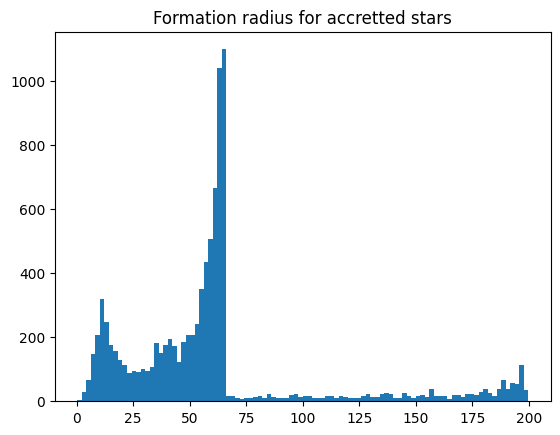

In [24]:
sel =  (f.s['r']>4)& (f.s['r']<30) & accreted
plt.title('Formation radius for accretted stars')
plt.hist(Rform[sel], bins=100)

plt.show()

# PID example

In [27]:
snap = '1000'
sel= 5
name = names1[sel]
print(name)

sss = folder1+"{}/Files/jrun003.{}.0{}.gz".format(name,name,snap)

f = pynbody.load(sss)
f.physical_units()
pynbody.analysis.angmom.faceon(f.stars);
f = pynbody.load(sss)
f.physical_units()
pynbody.analysis.angmom.faceon(f.stars);
'''
the file containing stars are structured in a way that new stars are appended to the file.
So, e.g., if snap '0100' has 1000 stars, and snap '0200 has 1500 stars, the first 1000 stars from the latter are exactly the same stars in the former.
We can then assign a "pid" for each star which allow us to identify them in every snapshot. 
'''

f.s["pid"] = np.arange(0,len(f.s),1) 


dwarfM06XY138Z37Vxy20FB20


In [29]:
sel =  (f.s['r']>4)& (f.s['r']<30) & (f.s['vphi']<0)
retro = f.s['pid'][sel] #these are the indices of the retrograde stars


SimArray([      3,       8,      60, ..., 1139926, 1172598, 1178205])

In [30]:
snap = '0500'
sel= 5
name = names1[sel]
print(name)

sss = folder1+"{}/Files/jrun003.{}.0{}.gz".format(name,name,snap)

f = pynbody.load(sss)
f.physical_units()
pynbody.analysis.angmom.faceon(f.stars);
f = pynbody.load(sss)
f.physical_units()
pynbody.analysis.angmom.faceon(f.stars);

f.s["pid"] = np.arange(0,len(f.s),1) 


dwarfM06XY138Z37Vxy20FB20


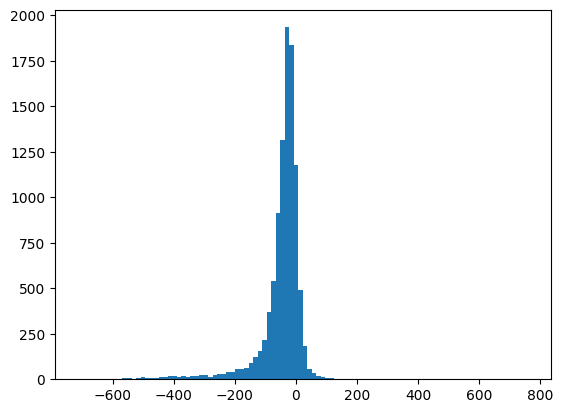

In [33]:
'''
the vphi distribution at t=5 Gyr, for the stars which are retrograde at snap t=10 Gyr
'''
plt.hist(f.s['vphi'][retro], bins=100)
plt.show()

# Plot examples

In [24]:
'''
below is just an example of loading two models.

For now, what matter is the difference between clumpy and non-clumpy.

Clumpy models are named with "FB20" or "FB02" at the end

'''


snap = '1000'
sel= 4
name = names1[sel]
print(name)

sss = folder1+"{}/Files/jrun003.{}.0{}.gz".format(name,name,snap)


f = pynbody.load(sss)
f.physical_units() # need to do to convert units
pynbody.analysis.angmom.faceon(f.stars); #this aligns the galaxy based on the vertical angular momentum of the stars
f.s["pid"] = np.arange(0,len(f.s),1)
pid_acc = np.load(datafold+"accreted_files/{}_pid_accreted.npy".format(name))
accreted = np.isin(f.s['pid'], pid_acc)



sel = 5
name = names1[sel]
print(name)

sss = folder1+"{}/Files/jrun003.{}.0{}.gz".format(name,name,snap)


f2 = pynbody.load(sss)
f2.physical_units()
pynbody.analysis.angmom.faceon(f2.stars);
f2.s["pid"] = np.arange(0,len(f2.s),1)
pid_acc = np.load(datafold+"accreted_files/{}_pid_accreted.npy".format(name))
accreted2 = np.isin(f2.s['pid'], pid_acc)



dwarfM06XY138Z37Vxy20
dwarfM06XY138Z37Vxy20FB20


In [25]:
print(f.keys())

['pos', 'x', 'y', 'z', 'vel', 'vx', 'vy', 'vz', 'mass', 'eps', 'phi']


In [26]:
print(f.derivable_keys())

['HII', 'HeIII', 'ne', 'hetot', 'hydrogen', 'feh', 'oxh', 'ofe', 'mgfe', 'nefe', 'sife', 'c_s', 'c_s_turb', 'mjeans', 'mjeans_turb', 'ljeans', 'ljeans_turb', 'U_mag', 'U_lum_den', 'B_mag', 'B_lum_den', 'V_mag', 'V_lum_den', 'R_mag', 'R_lum_den', 'I_mag', 'I_lum_den', 'J_mag', 'J_lum_den', 'H_mag', 'H_lum_den', 'K_mag', 'K_lum_den', 'u_mag', 'u_lum_den', 'g_mag', 'g_lum_den', 'r_mag', 'r_lum_den', 'i_mag', 'i_lum_den', 'z_mag', 'z_lum_den', 'y_mag', 'y_lum_den', 'r', 'rxy', 'vr', 'v2', 'vt', 'ke', 'te', 'j', 'j2', 'jz', 'vrxy', 'vcxy', 'vphi', 'vtheta', 'v_mean', 'v_disp', 'v_curl', 'vorticity', 'v_div', 'age', 'theta', 'alt', 'az', 'cs', 'mu', 'p', 'u', 'temp', 'zeldovich_offset', 'aform', 'tform', 'iord_argsort', 'smooth', 'rho']


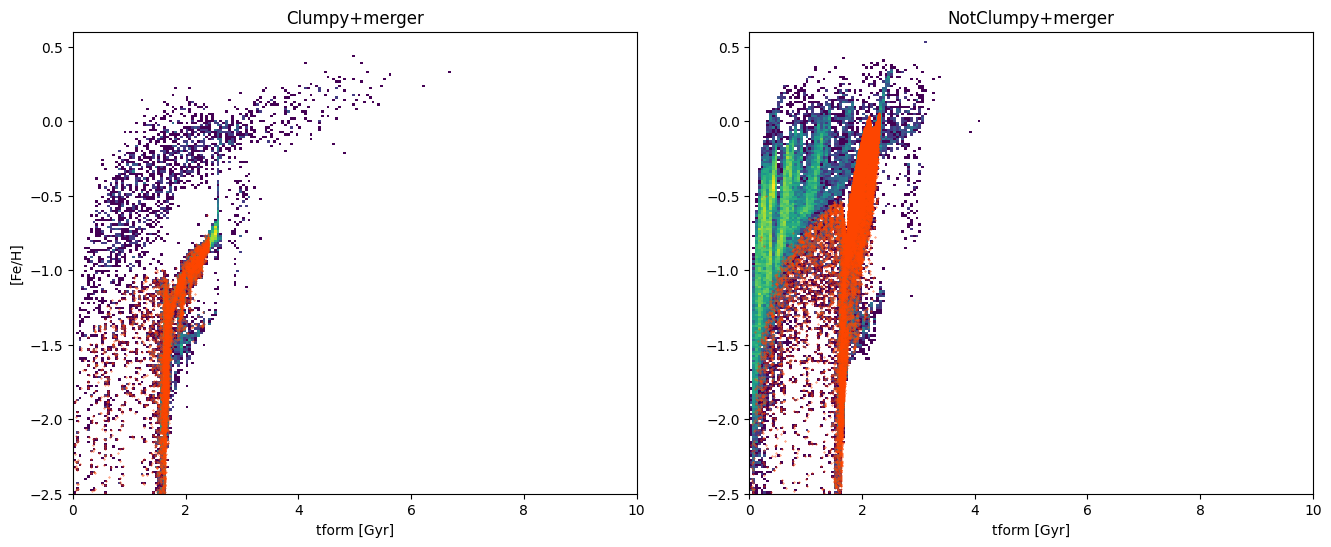

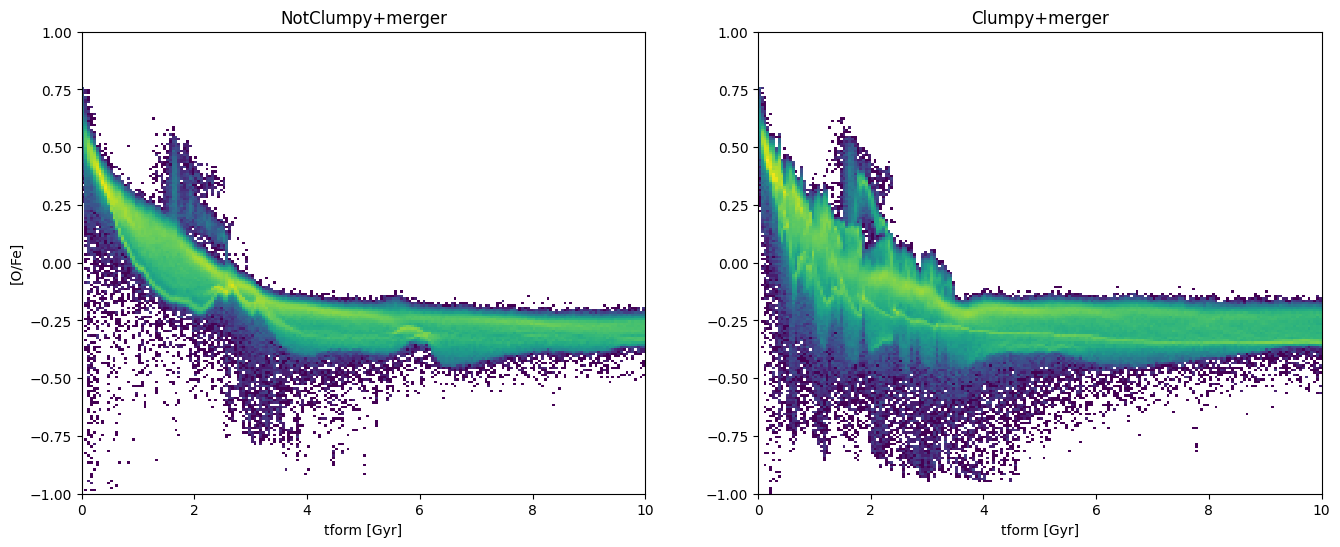

In [36]:
'''
just an example, I usually plot in a more efficient way, but this is for illustration purpose


'''

fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(16,6))



vphimin = 100
rmin = 4


sel = (f.s['vphi']<vphimin) & (f.s['r']>rmin) 
ax1.hist2d(f.s['tform'][sel], f.s['feh'][sel], range=((0,10),(-2.5,0.6)), bins=200, norm=LogNorm())
sel = accreted
ax1.scatter(f.s['tform'][sel], f.s['feh'][sel], s=0.1, color='orangered')
sel = (f2.s['vphi']<vphimin) & (f2.s['r']>rmin) 
ax2.hist2d(f2.s['tform'][sel], f2.s['feh'][sel], range=((0,10),(-2.5,0.6)), bins=200, norm=LogNorm())
sel = accreted2
ax2.scatter(f2.s['tform'][sel], f2.s['feh'][sel], s=0.1, color='orangered')



ax1.set_xlabel('tform [Gyr]')
ax2.set_xlabel('tform [Gyr]')

ax1.set_ylabel('[Fe/H]')

ax1.set_title('Clumpy+merger')
ax2.set_title('NotClumpy+merger')
# ax2.set_title('$v_{{\\phi}}< {}$ km/s \& $r>{}$ kpc'.format(vphimin, rmin))
plt.show()


#######################################
####
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(16,6))

ax1.hist2d(f.s['tform'], f.s['ofe'], range=((0,10),(-1,1)), bins=200, norm=LogNorm())

vphimin = 100
rmin = 4

sel = (f.s['vphi']<vphimin) & (f.s['r']>rmin) 
# sel = accreted
# axx = ax2.hist2d(f.s['tform'][sel], f.s['ofe'][sel], range=((0,10),(-1,1)), bins=200, norm=LogNorm())
ax2.hist2d(f2.s['tform'], f2.s['ofe'], range=((0,10),(-1,1)), bins=200, norm=LogNorm())


ax1.set_xlabel('tform [Gyr]')
ax2.set_xlabel('tform [Gyr]')

ax1.set_ylabel('[O/Fe]')

# ax1.set_title('all')
# ax2.set_title('$v_{{\\phi}}< {}$ km/s \& $r>{}$ kpc'.format(vphimin, rmin))
ax2.set_title('Clumpy+merger')
ax1.set_title('NotClumpy+merger')

plt.show()

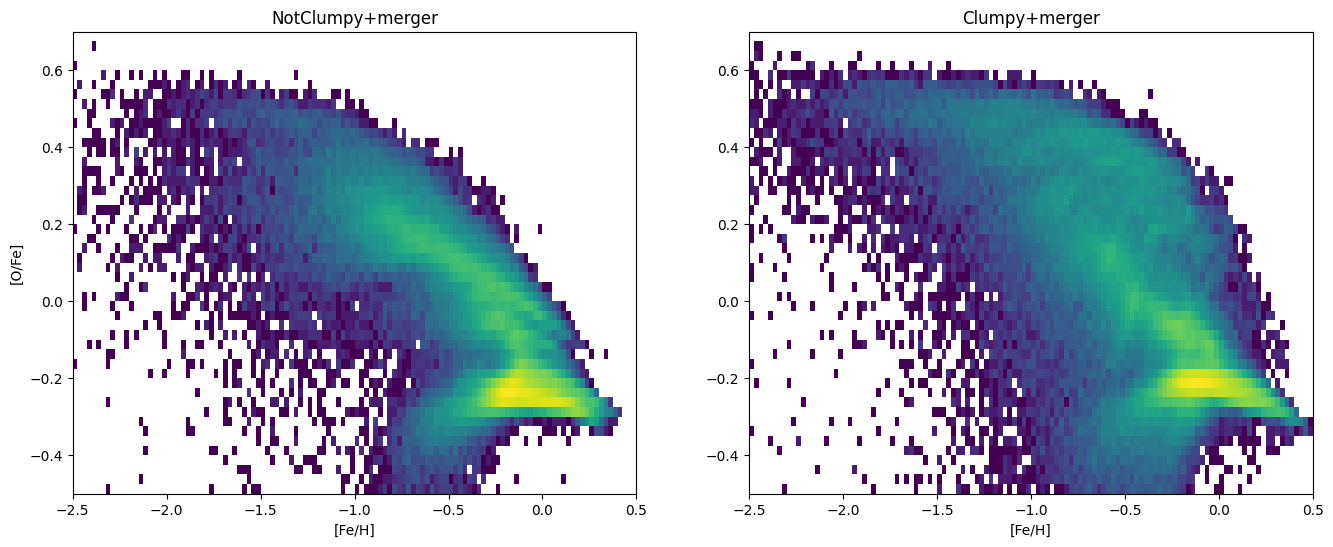

In [28]:
'''
example of selecting stars in a given radial range
'''
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(16,6))
sel = (f.s['rxy']>5) & (f.s['rxy']<12)

ax1.hist2d(f.s['feh'][sel], f.s['ofe'][sel], range=((-2.5,0.5),(-0.5,0.7)), bins=(120,48), norm=LogNorm())


sel = (f2.s['rxy']>5) & (f2.s['rxy']<12)

ax2.hist2d(f2.s['feh'][sel], f2.s['ofe'][sel], range=((-2.5,0.5),(-0.5,0.7)), bins=(120,48), norm=LogNorm())
ax1.set_xlabel('[Fe/H]')
ax2.set_xlabel('[Fe/H]')
ax1.set_ylabel('[O/Fe]')

ax2.set_title('Clumpy+merger')
ax1.set_title('NotClumpy+merger')
plt.show()